In [1]:
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np

customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
events = pd.read_csv('events.csv')

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Events:", events.shape)

customers.head()

Customers: (6000, 6)
Orders: (8400, 8)
Events: (15516, 3)


,customer_id,signup_date,acquisition_channel,country,age_band,gender
0,CUST00001,2024-09-11,Influencer,UAE,25-34,Female
1,CUST00002,2025-06-30,Organic/SEO,UK,45-54,Female
2,CUST00003,2025-02-26,Google Ads,UAE,25-34,Female
3,CUST00004,2024-12-13,Meta Ads,UAE,35-44,Female
4,CUST00005,2024-05-06,Meta Ads,India,35-44,Female


In [2]:
# Convert date columns to actual dates
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# Find the "today" reference point — the most recent date in the dataset
max_date = orders['order_date'].max()
print("Reference 'today' date:", max_date)

# For each customer, find their most recent order
last_order = orders.groupby('customer_id')['order_date'].max().reset_index()
last_order.columns = ['customer_id', 'last_order_date']

# Merge into customers table
customers = customers.merge(last_order, on='customer_id', how='left')

# Days since last order
customers['days_since_last_order'] = (max_date - customers['last_order_date']).dt.days

# Churn label: 1 if no order in last 90 days OR never ordered at all
customers['churned'] = ((customers['days_since_last_order'] > 90) | (customers['last_order_date'].isna())).astype(int)

print("\nChurn rate:", customers['churned'].mean().round(3))
customers[['customer_id', 'last_order_date', 'days_since_last_order', 'churned']].head(10)

Reference 'today' date: 2025-08-02 00:00:00

Churn rate: 0.809


,customer_id,last_order_date,days_since_last_order,churned
0,CUST00001,2024-11-16,259.0,1
1,CUST00002,2025-07-02,31.0,0
2,CUST00003,2025-04-21,103.0,1
3,CUST00004,2024-12-14,231.0,1
4,CUST00005,2024-05-06,453.0,1
5,CUST00006,2024-05-08,451.0,1
6,CUST00007,2024-03-07,513.0,1
7,CUST00008,2025-07-17,16.0,0
8,CUST00009,2024-12-14,231.0,1
9,CUST00010,2025-02-14,169.0,1


In [3]:
# Frequency: how many orders each customer placed
order_counts = orders.groupby('customer_id')['order_id'].count().reset_index()
order_counts.columns = ['customer_id', 'total_orders']

# Monetary: total revenue per customer
total_revenue = orders.groupby('customer_id')['revenue'].sum().reset_index()
total_revenue.columns = ['customer_id', 'total_revenue']

# Average discount usage (proxy for price sensitivity)
avg_discount = orders.groupby('customer_id')['discount_pct'].mean().reset_index()
avg_discount.columns = ['customer_id', 'avg_discount_pct']

# Merge all into customers table
customers = customers.merge(order_counts, on='customer_id', how='left')
customers = customers.merge(total_revenue, on='customer_id', how='left')
customers = customers.merge(avg_discount, on='customer_id', how='left')

# Fill missing values for customers with zero orders (shouldn't happen much, but safety net)
customers['total_orders'] = customers['total_orders'].fillna(0)
customers['total_revenue'] = customers['total_revenue'].fillna(0)
customers['avg_discount_pct'] = customers['avg_discount_pct'].fillna(0)

customers[['customer_id', 'total_orders', 'total_revenue', 'avg_discount_pct', 'churned']].head(10)

,customer_id,total_orders,total_revenue,avg_discount_pct,churned
0,CUST00001,3.0,130.2,3.333333,1
1,CUST00002,1.0,24.0,0.000000,0
2,CUST00003,2.0,48.0,0.000000,1
3,CUST00004,1.0,78.0,0.000000,1
4,CUST00005,1.0,16.0,20.000000,1
5,CUST00006,1.0,32.0,0.000000,1
6,CUST00007,1.0,16.0,0.000000,1
7,CUST00008,3.0,97.4,3.333333,0
8,CUST00009,1.0,38.0,0.000000,1
9,CUST00010,1.0,38.0,0.000000,1


In [4]:
# Count total engagement events per customer (site visits, cart adds, etc.)
event_counts = events.groupby('customer_id').size().reset_index(name='total_events')

# Count specific high-intent events: cart abandons (signals interest but hesitation)
cart_abandons = events[events['event_type'] == 'cart_abandon'].groupby('customer_id').size().reset_index(name='cart_abandon_count')

# Merge into customers table
customers = customers.merge(event_counts, on='customer_id', how='left')
customers = customers.merge(cart_abandons, on='customer_id', how='left')

# Fill missing values (customers with zero events)
customers['total_events'] = customers['total_events'].fillna(0)
customers['cart_abandon_count'] = customers['cart_abandon_count'].fillna(0)

customers[['customer_id', 'total_orders', 'total_revenue', 'total_events', 'cart_abandon_count', 'churned']].head(10)

,customer_id,total_orders,total_revenue,total_events,cart_abandon_count,churned
0,CUST00001,3.0,130.2,2,0.0,1
1,CUST00002,1.0,24.0,5,1.0,0
2,CUST00003,2.0,48.0,3,0.0,1
3,CUST00004,1.0,78.0,3,1.0,1
4,CUST00005,1.0,16.0,1,0.0,1
5,CUST00006,1.0,32.0,1,0.0,1
6,CUST00007,1.0,16.0,1,0.0,1
7,CUST00008,3.0,97.4,7,1.0,0
8,CUST00009,1.0,38.0,2,0.0,1
9,CUST00010,1.0,38.0,5,0.0,1


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns into numbers (models need numbers, not text)
le_channel = LabelEncoder()
le_country = LabelEncoder()
le_age = LabelEncoder()
le_gender = LabelEncoder()

customers['acquisition_channel_enc'] = le_channel.fit_transform(customers['acquisition_channel'])
customers['country_enc'] = le_country.fit_transform(customers['country'])
customers['age_band_enc'] = le_age.fit_transform(customers['age_band'])
customers['gender_enc'] = le_gender.fit_transform(customers['gender'])

# Select features for the model
features = ['acquisition_channel_enc', 'country_enc', 'age_band_enc', 'gender_enc',
            'total_orders', 'total_revenue', 'avg_discount_pct', 
            'total_events', 'cart_abandon_count']

X = customers[features]
y = customers['churned']

# Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

Training set: (4800, 9)
Test set: (1200, 9)
Churn rate in train: 0.809
Churn rate in test: 0.809


In [6]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Calculate class weight to handle the 80/20 imbalance
# This tells the model "pay more attention to the minority class (non-churned customers)"
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight:", round(scale_pos_weight, 2))

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 3))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

Scale pos weight: 0.24

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.62      0.88      0.73       229
           1       0.97      0.87      0.92       971

    accuracy                           0.88      1200
   macro avg       0.80      0.88      0.82      1200
weighted avg       0.90      0.88      0.88      1200

ROC-AUC Score: 0.951

--- Confusion Matrix ---
[[202  27]
 [122 849]]


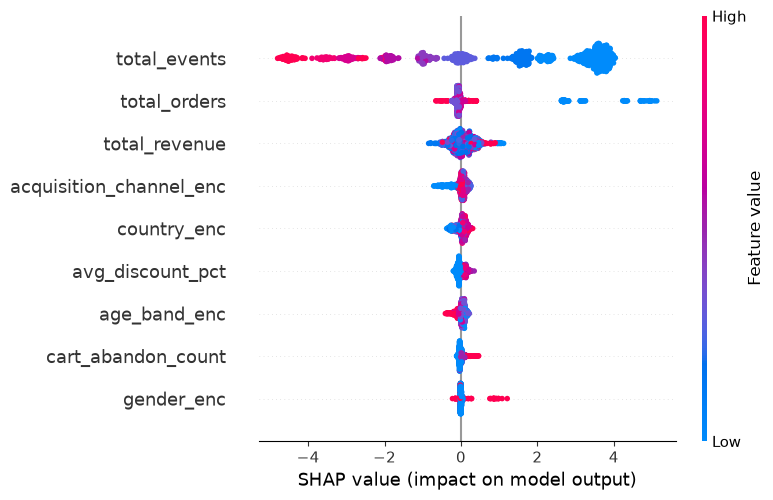

In [8]:
import shap

# Reset index so SHAP doesn't get confused by scattered row numbers
X_test_reset = X_test.reset_index(drop=True)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_reset)

# Summary plot - shows which features matter most overall
shap.summary_plot(shap_values, X_test_reset, feature_names=features)

Actual churned: 1
Predicted churn probability: 0.981


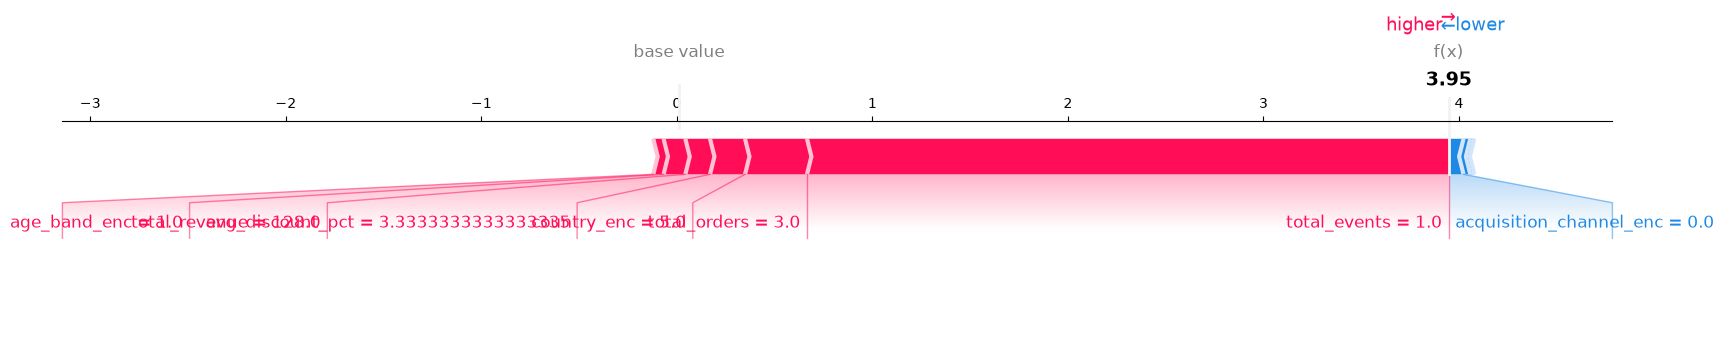

In [9]:
# Pick one high-risk customer from the test set
sample_idx = 0  # first customer in test set
print("Actual churned:", y_test.iloc[sample_idx])
print("Predicted churn probability:", round(y_pred_proba[sample_idx], 3))

shap.force_plot(explainer.expected_value, shap_values[sample_idx], X_test_reset.iloc[sample_idx], 
                 feature_names=features, matplotlib=True)